In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/208.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/45.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/56.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/89.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/20.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/275.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/212.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/239.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/58.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/150.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/validation/Fried food/6.jpg
/kaggle/input/datasets/trolukovich/food11-image-dataset/valid

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/trolukovich/food11-image-dataset


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

2026-04-07 16:24:00.795299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775579040.831312     755 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775579040.843060     755 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775579040.870347     755 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775579040.870371     755 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775579040.870375     755 computation_placer.cc:177] computation placer alr

In [4]:
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset"

img_size = (128, 128)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/training",
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/validation",
    image_size=img_size,
    batch_size=batch_size
)

Found 9866 files belonging to 11 classes.


I0000 00:00:1775579050.779935     755 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775579050.785033     755 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3430 files belonging to 11 classes.


In [5]:
class_names = train_data.class_names

In [6]:
num_classes = len(class_names)
print("Classes:", num_classes)

Classes: 11


In [7]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/training",
    image_size=img_size,
    batch_size=batch_size
)

Found 9866 files belonging to 11 classes.


In [8]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

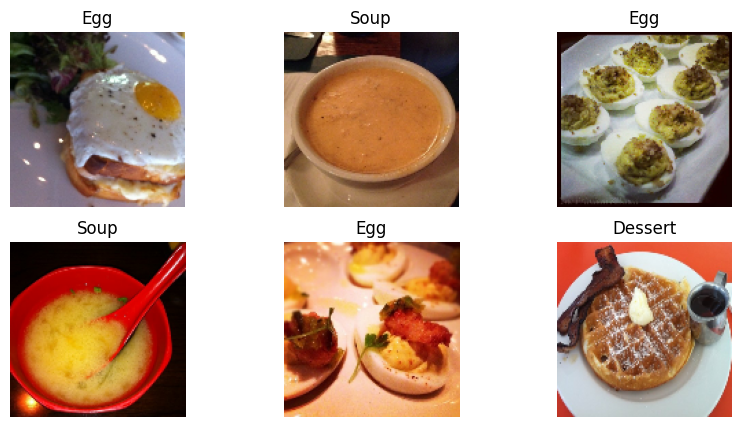

In [9]:
plt.figure(figsize=(10, 5))
for images, labels in train_data.take(1):
    for i in range(6):
        plt.subplot(2, 3, i+1)
        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())  # normalize for display
        plt.imshow(img)
        plt.title(class_names[labels[i]])   
        plt.axis("off")
plt.show()

In [10]:
LeNet_Model = models.Sequential([
    
    layers.Input(shape=(128,128,3)),   # ✅ FIX (no warning)
    
    layers.Conv2D(6, (5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),   # ✅ FIX
    
    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),   # ✅ FIX
    
    layers.Flatten(),
    
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
LeNet_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = LeNet_Model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


I0000 00:00:1775579055.354863     826 service.cc:152] XLA service 0x7f1f20009590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775579055.354911     826 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775579055.354915     826 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775579055.674706     826 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 16:24:16.466788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:24:16.602833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 12/309 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1325 - loss: 2.8773

I0000 00:00:1775579058.052040     826 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


309/309 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.1465 - loss: 2.3915 - val_accuracy: 0.1458 - val_loss: 2.3109
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.1427 - loss: 2.3070 - val_accuracy: 0.1458 - val_loss: 2.3071
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.1540 - loss: 2.3057 - val_accuracy: 0.1458 - val_loss: 2.3142
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.1569 - loss: 2.3035 - val_accuracy: 0.1458 - val_loss: 2.3069
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.1547 - loss: 2.3023 - val_accuracy: 0.1458 - val_loss: 2.3164


In [13]:
test_loss, test_acc = LeNet_Model.evaluate(val_data)
print("Accuracy:", test_acc)

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.1453 - loss: 2.3074
Accuracy: 0.14577259123325348


**LeNet**

Dataset shape: (5149, 128, 128, 3)


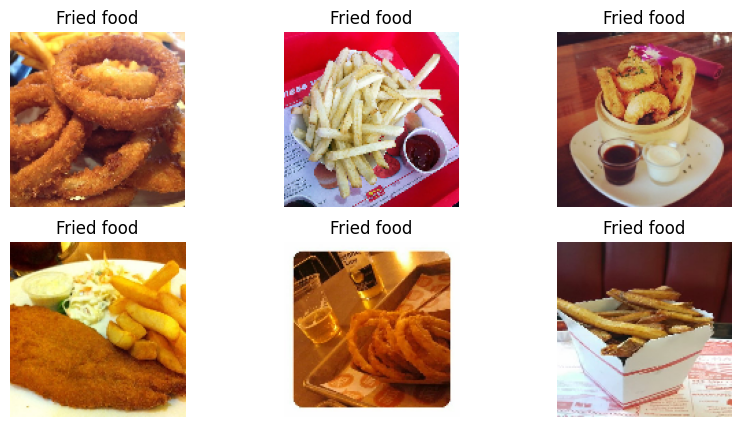

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 62, 62, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 29, 29, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │     1,614,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,811 (6.21 MB)

 Trainable params: 1,628,811 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.0980 - loss: 2.6624 - val_accuracy: 0.0883 - val_loss: 2.4275
Epoch 2/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0961 - loss: 2.4123 - val_accuracy: 0.0903 - val_loss: 2.4164
Epoch 3/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0909 - loss: 2.4109 - val_accuracy: 0.0951 - val_loss: 2.4051
Epoch 4/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0899 - loss: 2.4034 - val_accuracy: 0.1068 - val_loss: 2.4098
Epoch 5/5
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0859 - loss: 2.4048 - val_accuracy: 0.0883 - val_loss: 2.4043
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0781 - loss: 2.4127
Validation Accuracy: 0.08834951370954514


In [14]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import keras
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

# ================================
# 2. LOAD DATASET (LIKE MNIST STYLE)
# ================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
classes = os.listdir(path)

x = []
y = []

for label, folder in enumerate(classes):
    folder_path = os.path.join(path, folder)
    
    for img_name in os.listdir(folder_path)[:500]:   # limit per class (fast)
        img_path = os.path.join(folder_path, img_name)
        
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
        img = tf.keras.preprocessing.image.img_to_array(img)
        
        x.append(img)
        y.append(label)

# Convert to numpy
x = np.array(x)
y = np.array(y)

print("Dataset shape:", x.shape)

# ================================
# 3. VISUALIZE DATA
# ================================
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x[i].astype("uint8"))
    plt.title(classes[y[i]])
    plt.axis("off")
plt.show()

# ================================
# 4. NORMALIZE
# ================================
x = x / 255.0

# ================================
# 5. TRAIN-VALIDATION SPLIT
# ================================
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

# ================================
# 6. ONE-HOT ENCODING
# ================================
num_classes = len(classes)

y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)

# ================================
# 7. BUILD LeNet MODEL
# ================================
model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(128,128,3)))
model.add(AveragePooling2D((2,2)))

model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D((2,2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(num_classes, activation='softmax'))

# ================================
# 8. COMPILE
# ================================
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ================================
# 9. SUMMARY
# ================================
model.summary()

# ================================
# 10. TRAIN
# ================================
model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_val, y_val)
)

# ================================
# 11. EVALUATE
# ================================
loss, acc = model.evaluate(x_val, y_val)
print("Validation Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


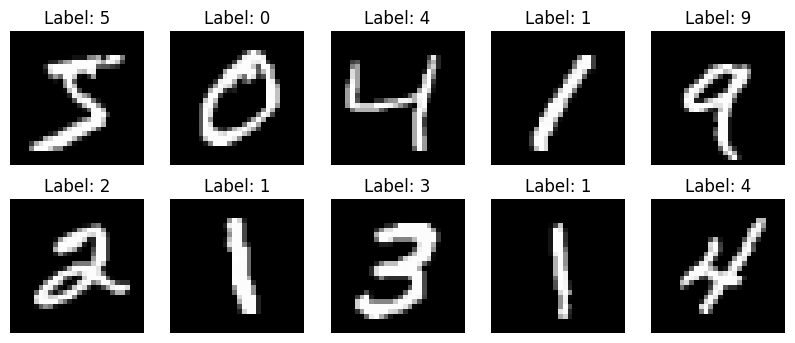

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8147 - loss: 0.6849 - val_accuracy: 0.9463 - val_loss: 0.1842
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9478 - loss: 0.1710 - val_accuracy: 0.9641 - val_loss: 0.1211
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9659 - loss: 0.1079 - val_accuracy: 0.9697 - val_loss: 0.0990
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9766 - loss: 0.0772 - val_accuracy: 0.9792 - val_loss: 0.0717
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0611 - val_accuracy: 0.9804 - val_loss: 0.0663
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0663
Test accuracy: 0.9810000061988831


In [15]:
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1)))
model.add(AveragePooling2D((2,2)))

model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D((2,2)))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)
     

AlexNet

Dataset shape: (7458, 128, 128, 3)


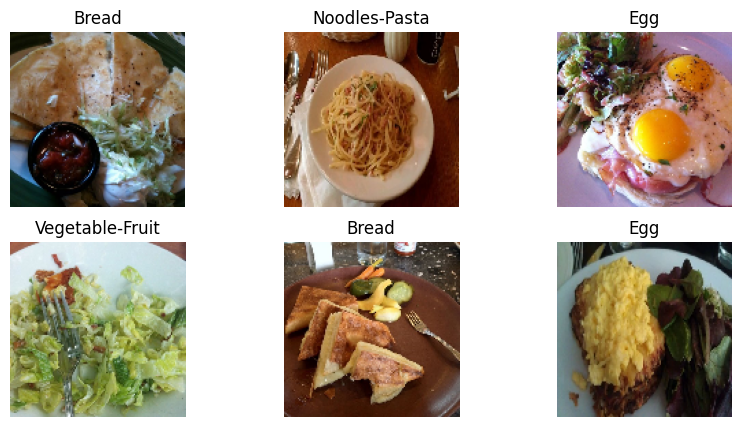

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,835 (1.17 MB)

 Trainable params: 305,387 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

...

Epoch 1/15


2026-04-07 16:26:59.116000: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:26:59.272354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:27:00.842736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:27:01.130692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 55/187 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.1390 - loss: 2.5548

2026-04-07 16:27:13.449279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:27:13.600280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:27:14.458503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:27:14.744713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


187/187 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.1782 - loss: 2.3747 - val_accuracy: 0.1072 - val_loss: 2.5689
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.2756 - loss: 2.0620 - val_accuracy: 0.1079 - val_loss: 3.4169
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.3216 - loss: 1.9650 - val_accuracy: 0.2084 - val_loss: 2.3641
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.3421 - loss: 1.8850 - val_accuracy: 0.3760 - val_loss: 1.7726
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.3692 - loss: 1.8300 - val_accuracy: 0.2942 - val_loss: 2.1052
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.3860 - loss: 1.7579 - val_accuracy: 0.3586 - val_loss: 2.2501
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.4274 - loss: 1.6885 - val_accuracy: 0.2668 - val_loss: 2.9919
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3497 - loss: 1.7912
Test Accuracy: 0.376

In [16]:
# =========================================
# 1. IMPORTS
# =========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt
import random

# =========================================
# 2. LOAD DATASET
# =========================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
classes = os.listdir(path)

X = []
Y = []

for label, folder in enumerate(classes):
    folder_path = os.path.join(path, folder)
    
    for img_name in os.listdir(folder_path)[:800]:
        img_path = os.path.join(folder_path, img_name)
        
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
        img = tf.keras.preprocessing.image.img_to_array(img)
        
        X.append(img)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:", X.shape)

# =========================================
# 3. SHOW IMAGES
# =========================================
plt.figure(figsize=(10,5))
for i in range(6):
    idx = random.randint(0, len(X)-1)
    plt.subplot(2,3,i+1)
    plt.imshow(X[idx].astype("uint8"))
    plt.title(classes[Y[idx]])
    plt.axis("off")
plt.show()

# =========================================
# 4. PREPROCESS
# =========================================
X = X / 255.0
num_classes = len(classes)
Y = to_categorical(Y, num_classes)

# =========================================
# 5. SPLIT
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y
)

# =========================================
# 6. DATA AUGMENTATION 🔥
# =========================================
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

# =========================================
# 7. BUILD IMPROVED VGG MODEL
# =========================================
model = Sequential()

model.add(tf.keras.layers.Input(shape=(128,128,3)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Efficient pooling
model.add(GlobalAveragePooling2D())

# Fully connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))

model.add(Dense(num_classes, activation='softmax'))

# =========================================
# 8. COMPILE (LOW LR 🔥)
# =========================================
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================
# 9. EARLY STOPPING
# =========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =========================================
# 10. TRAIN
# =========================================
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

# =========================================
# 11. EVALUATE
# =========================================
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)


Dataset shape: (7458, 128, 128, 3)


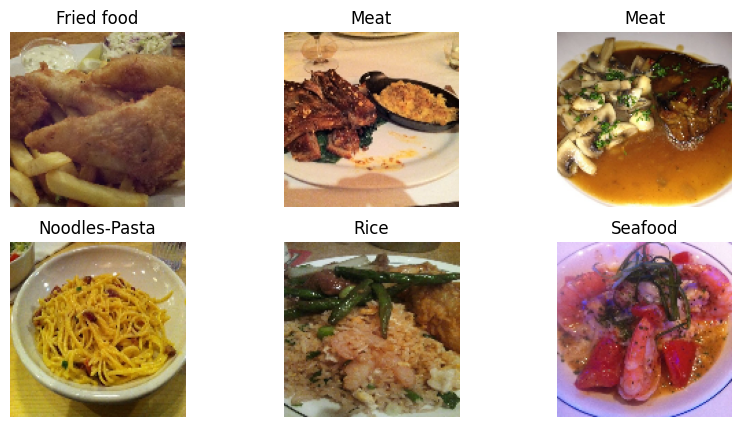

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,859 (24.87 MB)

 Trainable params: 6,518,859 (24.87 MB)

...

Epoch 1/10


2026-04-07 16:30:23.161946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:30:23.310350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


157/187 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.1362 - loss: 2.3406

2026-04-07 16:30:42.450826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-07 16:30:42.595698: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


187/187 ━━━━━━━━━━━━━━━━━━━━ 30s 134ms/step - accuracy: 0.1449 - loss: 2.3234 - val_accuracy: 0.2808 - val_loss: 1.9875
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.2794 - loss: 2.0226 - val_accuracy: 0.3519 - val_loss: 1.8558
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.3232 - loss: 1.9231 - val_accuracy: 0.3572 - val_loss: 1.8267
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.3468 - loss: 1.8558 - val_accuracy: 0.3887 - val_loss: 1.8372
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.3943 - loss: 1.7519 - val_accuracy: 0.4223 - val_loss: 1.6307
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.3922 - loss: 1.7389 - val_accuracy: 0.4424 - val_loss: 1.6723
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.4380 - loss: 1.6489 - val_accuracy: 0.4658 - val_loss: 1.5526
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.4560 - loss: 1.5853 - val

In [17]:
# =========================================
# 1. IMPORTS
# =========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# =========================================
# 2. LOAD DATASET
# =========================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
classes = os.listdir(path)

X = []
Y = []

for label, folder in enumerate(classes):
    folder_path = os.path.join(path, folder)
    
    for img_name in os.listdir(folder_path)[:800]:   # 🔥 increased data
        img_path = os.path.join(folder_path, img_name)
        
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
        img = tf.keras.preprocessing.image.img_to_array(img)
        
        X.append(img)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:", X.shape)

# =========================================
# 3. SHOW IMAGES
# =========================================
plt.figure(figsize=(10,5))

for i in range(6):
    idx = random.randint(0, len(X)-1)
    
    plt.subplot(2,3,i+1)
    plt.imshow(X[idx].astype("uint8"))
    plt.title(classes[Y[idx]])
    plt.axis("off")

plt.show()

# =========================================
# 4. NORMALIZE
# =========================================
X = X / 255.0

# =========================================
# 5. ONE-HOT ENCODING
# =========================================
num_classes = len(classes)
Y = to_categorical(Y, num_classes)

# =========================================
# 6. SPLIT DATA
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y
)

# =========================================
# 7. DATA AUGMENTATION 🔥
# =========================================
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

# =========================================
# 8. IMPROVED CNN MODEL (Better than AlexNet)
# =========================================
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

# =========================================
# 9. COMPILE
# =========================================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================
# 10. TRAIN 🔥
# =========================================
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, Y_test)
)

# =========================================
# 11. EVALUATE
# =========================================
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)

VGG MODEL

Dataset shape: (7458, 128, 128, 3)


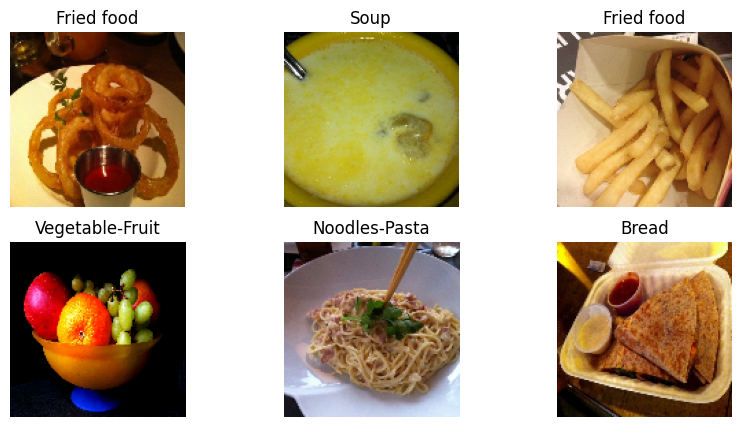

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,835 (1.17 MB)

 Trainable params: 305,387 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step - accuracy: 0.1876 - loss: 2.3620 - val_accuracy: 0.1072 - val_loss: 2.7627
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.2656 - loss: 2.1003 - val_accuracy: 0.1092 - val_loss: 3.0855
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.3043 - loss: 2.0007 - val_accuracy: 0.1910 - val_loss: 2.2537
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.3443 - loss: 1.9057 - val_accuracy: 0.3666 - val_loss: 1.8551
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.3645 - loss: 1.8276 - val_accuracy: 0.3244 - val_loss: 1.9735
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 22s 115ms/step - accuracy: 0.3792 - loss: 1.8041 - val_accuracy: 0.3391 - val_loss: 1.9801
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.4115 - loss: 1.7404 - val_accuracy: 0.4283 - val_loss: 1.6915
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.4206 - loss: 1

In [18]:
# =========================================
# 1. IMPORTS
# =========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import os
import matplotlib.pyplot as plt
import random

# =========================================
# 2. LOAD DATASET
# =========================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
classes = os.listdir(path)

X = []
Y = []

for label, folder in enumerate(classes):
    folder_path = os.path.join(path, folder)
    
    for img_name in os.listdir(folder_path)[:800]:
        img_path = os.path.join(folder_path, img_name)
        
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_size, img_size))
        img = tf.keras.preprocessing.image.img_to_array(img)
        
        X.append(img)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:", X.shape)

# =========================================
# 3. SHOW IMAGES
# =========================================
plt.figure(figsize=(10,5))
for i in range(6):
    idx = random.randint(0, len(X)-1)
    plt.subplot(2,3,i+1)
    plt.imshow(X[idx].astype("uint8"))
    plt.title(classes[Y[idx]])
    plt.axis("off")
plt.show()

# =========================================
# 4. PREPROCESS
# =========================================
X = X / 255.0
num_classes = len(classes)
Y = to_categorical(Y, num_classes)

# =========================================
# 5. SPLIT
# =========================================
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y
)

# =========================================
# 6. DATA AUGMENTATION 🔥
# =========================================
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

# =========================================
# 7. BUILD IMPROVED VGG MODEL
# =========================================
model = Sequential()

model.add(tf.keras.layers.Input(shape=(128,128,3)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Efficient pooling
model.add(GlobalAveragePooling2D())

# Fully connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))

model.add(Dense(num_classes, activation='softmax'))

# =========================================
# 8. COMPILE (LOW LR 🔥)
# =========================================
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================
# 9. EARLY STOPPING
# =========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# =========================================
# 10. TRAIN
# =========================================
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

# =========================================
# 11. EVALUATE
# =========================================
loss, acc = model.evaluate(X_test, Y_test)
print("Test Accuracy:", acc)


ZFNET

Found 7896 images belonging to 11 classes.
Found 1970 images belonging to 11 classes.


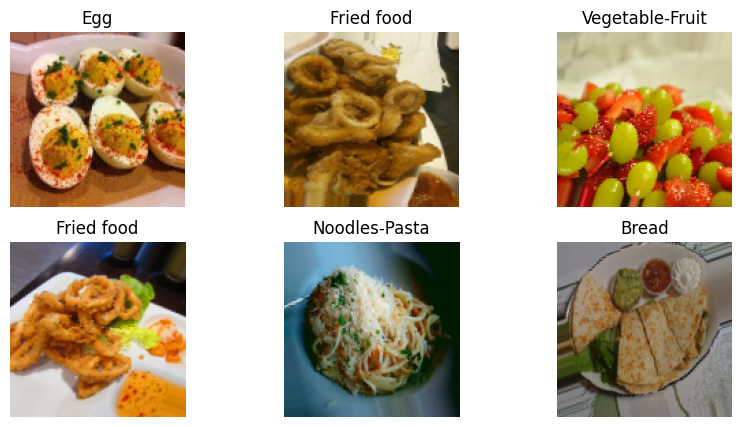

Model: "functional_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,075 (437.79 KB)

 Trainable params: 111,627 (436.04 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 68s 257ms/step - accuracy: 0.2047 - loss: 2.2989 - val_accuracy: 0.1569 - val_loss: 2.5823
Epoch 2/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 59s 239ms/step - accuracy: 0.2977 - loss: 2.0133 - val_accuracy: 0.1706 - val_loss: 2.6983
Epoch 3/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 59s 239ms/step - accuracy: 0.3484 - loss: 1.8976 - val_accuracy: 0.3635 - val_loss: 1.8981
Epoch 4/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 258ms/step - accuracy: 0.3749 - loss: 1.8141 - val_accuracy: 0.3924 - val_loss: 1.7634
Epoch 5/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 69s 278ms/step - accuracy: 0.3880 - loss: 1.7761 - val_accuracy: 0.3964 - val_loss: 1.7525
Epoch 6/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 59s 240ms/step - accuracy: 0.4080 - loss: 1.7328 - val_accuracy: 0.4208 - val_loss: 1.6543
Epoch 7/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 59s 237ms/step - accuracy: 0.4243 - loss: 1.6667 - val_accuracy: 0.4198 - val_loss: 1.6311
Epoch 8/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 58s 235ms/step - accuracy: 0.4432 - loss: 1

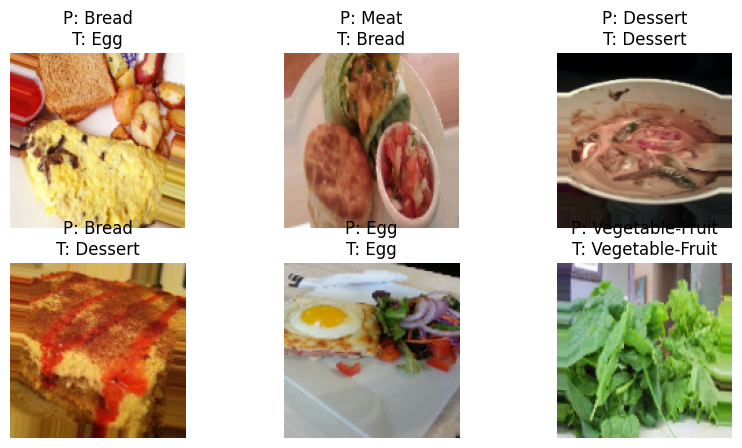

In [24]:
# =========================================
# 1. IMPORTS
# =========================================
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Dense
from tensorflow.keras.layers import BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# =========================================
# 2. LOAD DATA (FAST)
# =========================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes

# =========================================
# 3. SHOW SAMPLE IMAGES
# =========================================
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis("off")
plt.show()

# =========================================
# 4. BUILD MODEL
# =========================================
input_layer = Input(shape=(128,128,3))

x = Conv2D(32, (3,3), padding='same', activation='relu')(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# 🔥 Important fix
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.6)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

# =========================================
# 5. COMPILE
# =========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================
# 6. TRAIN
# =========================================
history = model.fit(
    train_data,
    epochs=12,
    validation_data=val_data
)

# =========================================
# 7. EVALUATE
# =========================================
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

# =========================================
# 8. SHOW PREDICTIONS 🔥
# =========================================
images, labels = next(val_data)

plt.figure(figsize=(10,5))

for i in range(6):
    img = images[i]
    
    pred = model.predict(img.reshape(1,128,128,3))
    
    pred_label = class_names[pred.argmax()]
    true_label = class_names[labels[i].argmax()]
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"P: {pred_label}\nT: {true_label}")
    plt.axis("off")

plt.show()

GoogleNet

Found 7896 images belonging to 11 classes.
Found 1970 images belonging to 11 classes.


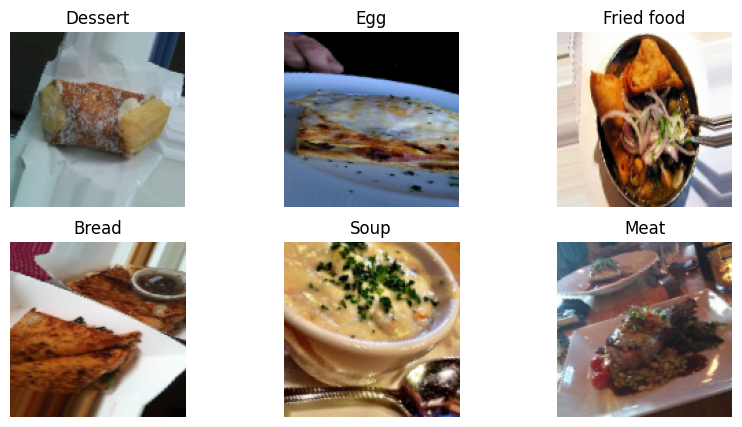

Model: "functional_67"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_14[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_93[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 128, 128,  │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 128, 128,  │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_31    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 128, 128,  │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 128, 128,  │     18,496 │ conv2d_95[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 128, 128,  │     51,264 │ conv2d_97[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 128, 128,  │      2,080 │ max_pooling2d_31… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 128, 128,  │          0 │ conv2d_94[0][0],  │
│ (Concatenate)       │ 192)              │            │ conv2d_96[0][0],  │
│                     │                   │            │ conv2d_98[0][0],  │
│                     │                   │            │ conv2d_99[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        768 │ concatenate_8[0]… │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 128, 128,  │      6,176 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 128, 128,  │      6,176 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 128, 128,  │      6,176 │ batch_normalizat… │
│                     │ 32)               │            │                 

 Total params: 297,483 (1.13 MB)

 Trainable params: 296,203 (1.13 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 136s 504ms/step - accuracy: 0.2283 - loss: 2.1870 - val_accuracy: 0.1523 - val_loss: 4.1907
Epoch 2/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 108s 437ms/step - accuracy: 0.3488 - loss: 1.9198 - val_accuracy: 0.1599 - val_loss: 2.6925
Epoch 3/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 111s 447ms/step - accuracy: 0.3898 - loss: 1.8070 - val_accuracy: 0.4086 - val_loss: 1.7225
Epoch 4/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 109s 441ms/step - accuracy: 0.4279 - loss: 1.6901 - val_accuracy: 0.4218 - val_loss: 1.7105
Epoch 5/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 109s 439ms/step - accuracy: 0.4564 - loss: 1.5946 - val_accuracy: 0.3645 - val_loss: 1.9674
Epoch 6/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 108s 436ms/step - accuracy: 0.4727 - loss: 1.5567 - val_accuracy: 0.4467 - val_loss: 1.5766
Epoch 7/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 111s 448ms/step - accuracy: 0.4963 - loss: 1.4754 - val_accuracy: 0.4335 - val_loss: 1.6494
Epoch 8/12
247/247 ━━━━━━━━━━━━━━━━━━━━ 109s 439ms/step - accuracy: 0.5206 -

In [27]:
# =========================================
# 1. IMPORTS
# =========================================
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Dense
from tensorflow.keras.layers import GlobalAveragePooling2D, concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# =========================================
# 2. DATA
# =========================================
path = "/kaggle/input/datasets/trolukovich/food11-image-dataset/training"

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes

# =========================================
# 3. SHOW IMAGES
# =========================================
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis("off")
plt.show()

# =========================================
# 4. STRONG INCEPTION MODULE
# =========================================
def inception_module(x):
    path1 = Conv2D(32, (1,1), activation='relu', padding='same')(x)

    path2 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path2 = Conv2D(64, (3,3), activation='relu', padding='same')(path2)

    path3 = Conv2D(32, (1,1), activation='relu', padding='same')(x)
    path3 = Conv2D(64, (5,5), activation='relu', padding='same')(path3)

    path4 = MaxPooling2D((3,3), strides=1, padding='same')(x)
    path4 = Conv2D(32, (1,1), activation='relu', padding='same')(path4)

    x = concatenate([path1, path2, path3, path4])
    x = BatchNormalization()(x)

    return x

# =========================================
# 5. MODEL
# =========================================
input_layer = Input(shape=(128,128,3))

x = Conv2D(64, (3,3), activation='relu', padding='same')(input_layer)
x = BatchNormalization()(x)

# 🔥 More depth
x = inception_module(x)
x = inception_module(x)

x = MaxPooling2D((2,2))(x)

x = inception_module(x)

# Efficient pooling
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

# =========================================
# 6. COMPILE
# =========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =========================================
# 7. TRAIN
# =========================================
history = model.fit(
    train_data,
    epochs=12,
    validation_data=val_data
)

# =========================================
# 8. EVALUATE
# =========================================
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

